In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from pathlib import Path

In [2]:
weather_plot_paths = {
    "transformer": "C:/Users/ADMIN/Downloads/timeserries_models_analysis/assets/weather/transformer_predictions.png",
    "lstm": "C:/Users/ADMIN/Downloads/timeserries_models_analysis/assets/weather/lstm_predictions.png",
    "rnn": "C:/Users/ADMIN/Downloads/timeserries_models_analysis/assets/weather/rnn_predictions.png",
    "mlp": "C:/Users/ADMIN/Downloads/timeserries_models_analysis/assets/weather/mlp_predictions.png"
}

apple_plot_paths = {
    "transformer": "C:/Users/ADMIN/Downloads/timeserries_models_analysis/assets/apple/transformer_predictions.png",
    "lstm": "C:/Users/ADMIN/Downloads/timeserries_models_analysis/assets/apple/lstm_predictions.png",
    "rnn": "C:/Users/ADMIN/Downloads/timeserries_models_analysis/assets/apple/rnn_predictions.png",
    "mlp": "C:/Users/ADMIN/Downloads/timeserries_models_analysis/assets/apple/mlp_predictions.png"
}

In [3]:
def show_single_plot(image_path, title=None, figsize=(12, 6)):
    img = mpimg.imread(image_path)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    if title:
        plt.title(title, fontsize=14)
    plt.show()


def show_plot_grid(plot_paths, dataset_name, cols=2, figsize=(18, 10)):
    models = list(plot_paths.keys())
    n = len(models)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()

    for ax, model in zip(axes, models):
        img = mpimg.imread(plot_paths[model])
        ax.imshow(img)
        ax.axis("off")

def check_files_exist(plot_paths, dataset_name):
    print(f"\nChecking {dataset_name} files:")
    for model, path in plot_paths.items():
        exists = Path(path).exists()
        print(f"{model:12s} {'OK' if exists else 'MISSING'} | {path}")

check_files_exist(weather_plot_paths, "weather")
check_files_exist(apple_plot_paths, "apple")


Checking weather files:
transformer  OK | C:/Users/ADMIN/Downloads/timeserries_models_analysis/assets/weather/transformer_predictions.png
lstm         OK | C:/Users/ADMIN/Downloads/timeserries_models_analysis/assets/weather/lstm_predictions.png
rnn          OK | C:/Users/ADMIN/Downloads/timeserries_models_analysis/assets/weather/rnn_predictions.png
mlp          OK | C:/Users/ADMIN/Downloads/timeserries_models_analysis/assets/weather/mlp_predictions.png

Checking apple files:
transformer  OK | C:/Users/ADMIN/Downloads/timeserries_models_analysis/assets/apple/transformer_predictions.png
lstm         OK | C:/Users/ADMIN/Downloads/timeserries_models_analysis/assets/apple/lstm_predictions.png
rnn          OK | C:/Users/ADMIN/Downloads/timeserries_models_analysis/assets/apple/rnn_predictions.png
mlp          OK | C:/Users/ADMIN/Downloads/timeserries_models_analysis/assets/apple/mlp_predictions.png


In [4]:
metric_ranking = {
    "weather": ["lstm", "rnn", "transformer", "mlp"],
    "apple": ["rnn", "lstm", "transformer", "mlp"]
}

for dataset, ranking in metric_ranking.items():
    print(f"{dataset.capitalize()} metric ranking: {' > '.join(ranking)}")

Weather metric ranking: lstm > rnn > transformer > mlp
Apple metric ranking: rnn > lstm > transformer > mlp


## Reference metric ranking

From the `comparison_model` notebook:

- **Weather:** LSTM > RNN > Transformer > MLP
- **Apple:** RNN > LSTM > Transformer > MLP

The purpose of this notebook is to check whether the visual prediction behavior supports these rankings.

### Comparative Interpretation of Prediction Plots

Comparing the prediction plots across the two datasets highlights how strongly dataset characteristics influence model behaviour. The Weather series is smooth, structured, and relatively regular, so all models are able to capture its general shape to some degree. However, sequence-aware models still provide the best fit, especially the RNN and LSTM, which track both long-term movement and local variation very closely.

The Apple series is much more difficult. Even after transforming the target into log returns, the series remains noisy, irregular, and dominated by short-term fluctuations rather than stable trend structure. As a result, all models produce smoother predictions than the true series, and none are able to reproduce extreme spikes accurately. In this setting, the advantage of sequence-based models becomes more important, because the task depends on learning subtle temporal relationships rather than broad trend following.

Another clear contrast is that on Weather, the RNN achieves the best visual match, whereas on Apple the Transformer and LSTM appear strongest. This shows that the most suitable architecture depends on the type of time series rather than model complexity alone. Simpler recurrent memory is sufficient for the smoother weather signal, while the noisier return-based Apple series benefits more from models that can represent more flexible sequential relationships.

Overall, the prediction plots support the conclusions from the evaluation metrics. Sequence models outperform the MLP on both datasets, but the strongest sequence architecture changes depending on the forecasting problem. This reinforces the idea that model selection in time series forecasting should be guided by the structure and behaviour of the data itself.

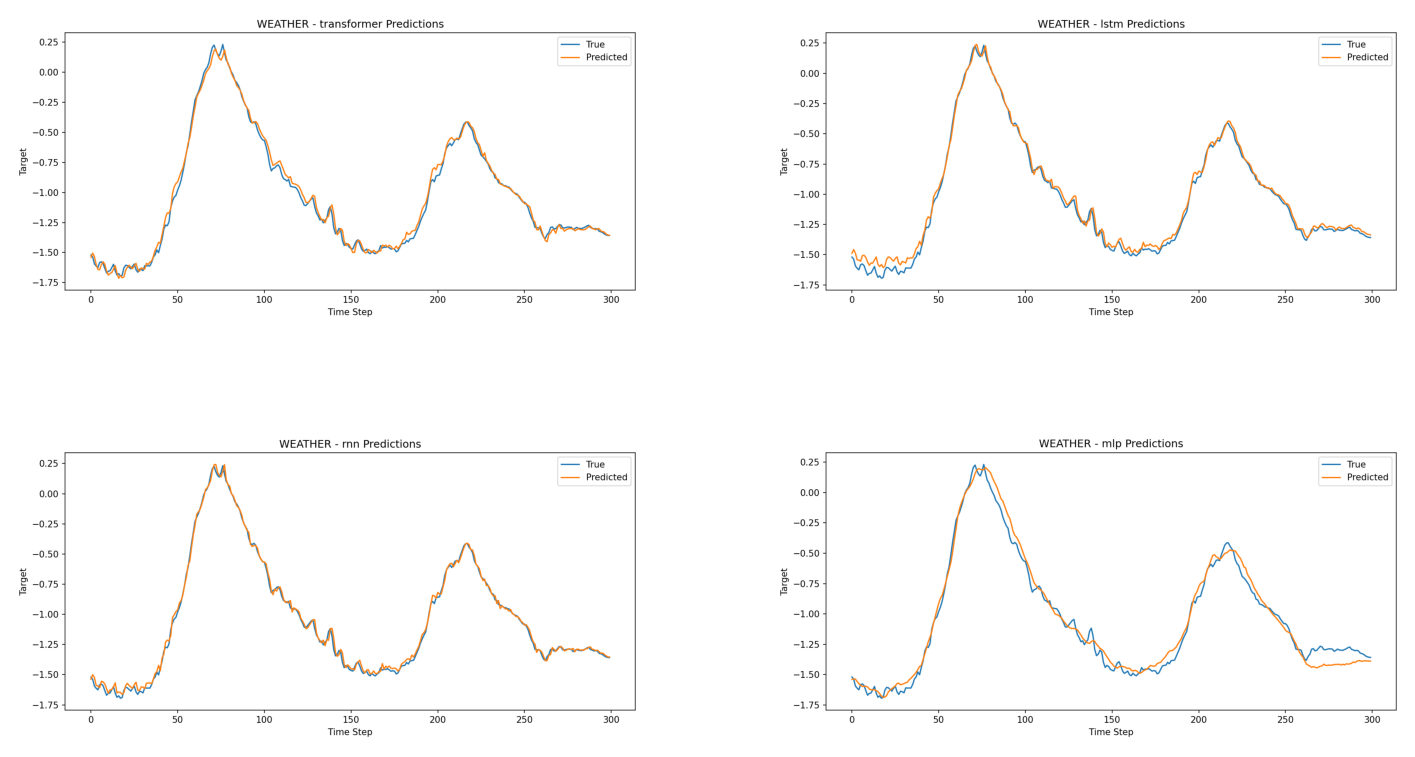

In [5]:
show_plot_grid(weather_plot_paths, dataset_name="weather", cols=2, figsize=(18, 10))

### Weather Plot Summary

The Weather prediction plots show that the RNN and LSTM produce the closest fit to the true series, with both models accurately following the main peak, the long decline, and the later rise. The Transformer captures the overall pattern well but is slightly less precise in local fluctuations, while the MLP appears smoother and less responsive. These plots confirm that recurrent models are the most effective for this structured and relatively smooth time series.

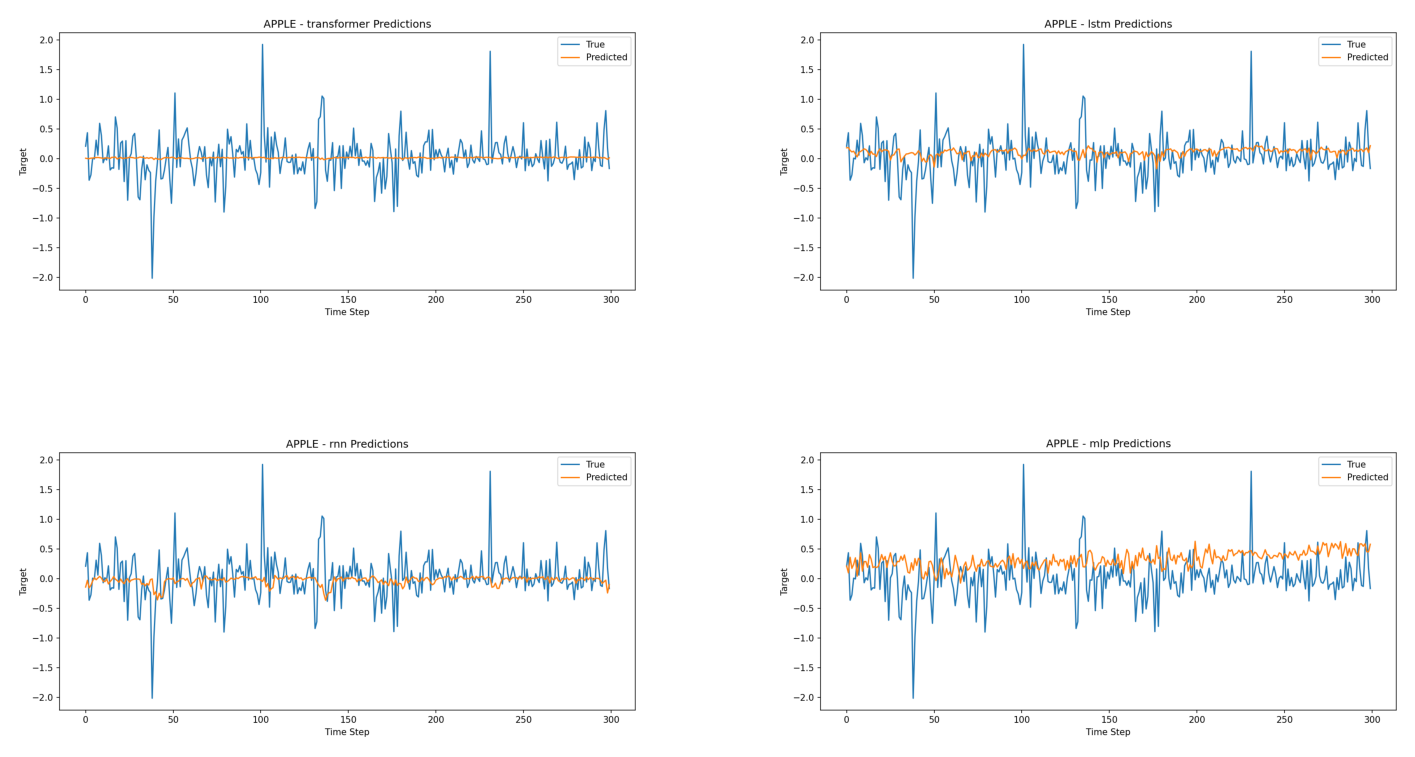

In [6]:
show_plot_grid(apple_plot_paths, dataset_name="apple", cols=2, figsize=(18, 10))

### Apple Plot Summary

The Apple prediction plots show a much harder forecasting task, with noisy log-return behaviour and frequent sharp fluctuations around zero. The Transformer and LSTM provide the best overall visual fit, as their predictions remain centered appropriately and follow the general movement pattern better than the RNN and MLP. The MLP performs worst, showing noticeable bias and weaker alignment with the true series. All models smooth out the largest spikes, which reflects the difficulty of predicting extreme financial return movements.

### Final Discussion

The prediction plots provide useful visual confirmation of the numerical evaluation results. For the Weather dataset, the RNN achieves the best balance between accuracy and responsiveness, with the LSTM also performing strongly. For the Apple dataset, the Transformer and LSTM appear more effective, suggesting that more flexible sequential modelling is helpful when the target is noisier and less regular.

These results show that forecasting quality should not be judged only by error metrics, but also by how well prediction curves follow the shape, timing, and variability of the true series. Combining both quantitative and visual analysis gives a more complete understanding of model behaviour and strengthens the final comparison.